
# Embedding sampling, TSNE and clustering of skills learned from Atari Crowdplay dataset




In [3]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import gym
from gym.wrappers import AtariPreprocessing
from VAE.atari.utils import load_ae_model
import torch
import numpy as np
import tqdm 
import pandas
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn import metrics
from sklearn.cluster import DBSCAN, KMeans 

2024-08-28 11:22:20.714483: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-28 11:22:23.734136: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-28 11:22:23.734246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-28 11:22:24.585893: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-28 11:22:25.654360: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
#! pip install numpy==1.23.1

## Data generation


In [4]:


def play_policy(env, model, num_eval=100, traj_length=10, tanh=True):
    model.eval()
    rewards = []
    latents = []
    data = []
    # for i in range(num_eval):
    for i in tqdm.tqdm(range(num_eval)):
        state = env.reset()
        state = torch.FloatTensor(state[0]).unsqueeze(0).unsqueeze(0)
        latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        latents.append(latent[0])
        d = {"latent": latent[0]}
        done = False
        reward = 0
        num_steps = 0
        actions = []
        while not done:
            # latents.append(latent[0])
            if tanh:
                latent = torch.tanh(latent)
            for t in range(traj_length):
                action, _ = model.decoder.act(latent, state, encode_state=True)
                action = action.cpu().numpy().flatten()[0]
                actions.append(action)
                s, r, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                reward += r
                num_steps += 1
                state = torch.FloatTensor(s).unsqueeze(0).unsqueeze(0)
                latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        actions_freq = {f"action_{i}":actions.count(i)/len(actions) for i in set(actions)}

        d.update(actions_freq)
        data.append(d)
        rewards.append(reward)
    print(numpy.mean(rewards))
    return rewards, latents, data

In [6]:
env = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env = AtariPreprocessing(env)
model = load_ae_model(env, "/home/sara/repositories/player_model_dt/VAE/atari/models/dataset_model/atari-100.pt")
rewards, skill_embeddings, data = play_policy(env, model)

X = numpy.array(skill_embeddings)
df = pandas.DataFrame(data)
df = df.fillna(0)
df

A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]
  0%|          | 0/100 [00:00<?, ?it/s]/home/sara/.venv/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
100%|██████████| 100/100 [06:07<00:00,  3.68s/it]

108.0


,latent,action_0,action_1,action_2,action_3,action_5,action_4
0,"[tensor(-0.0514), tensor(-0.0526), tensor(-0.0...",0.978261,0.004348,0.011594,0.005797,0.000000,0.000000
1,"[tensor(0.0017), tensor(0.0079), tensor(0.0143...",0.968116,0.018841,0.002899,0.005797,0.004348,0.000000
2,"[tensor(-0.0478), tensor(-0.0264), tensor(0.03...",0.405172,0.158621,0.101724,0.093103,0.036207,0.205172
3,"[tensor(-0.0150), tensor(0.0113), tensor(-0.04...",0.957971,0.026087,0.005797,0.010145,0.000000,0.000000
4,"[tensor(-0.0102), tensor(0.0026), tensor(-0.03...",0.584146,0.145122,0.135366,0.039024,0.028049,0.068293
...,...,...,...,...,...,...,...
95,"[tensor(-0.0007), tensor(0.0637), tensor(-0.04...",0.827451,0.109804,0.054902,0.005882,0.000000,0.001961
96,"[tensor(-0.0016), tensor(-0.0405), tensor(0.07...",0.331884,0.281159,0.094203,0.005797,0.089855,0.197101
97,"[tensor(-0.0079), tensor(-0.0269), tensor(-0.1...",0.988406,0.002899,0.001449,0.004348,0.001449,0.001449
98,"[tensor(-0.0094), tensor(-0.0467), tensor(-0.0...",0.862745,0.096078,0.039216,0.001961,0.000000,0.000000


In [5]:
def get_dataset_embeddings(model, dataset):
    embeddings = []
    for state in tqdm.tqdm(dataset['observations'][:20000][::2]):
        state = torch.FloatTensor(state[0]).unsqueeze(0).unsqueeze(0)
        latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        embeddings.append(latent[0])
    return embeddings

In [6]:
from VAE.atari.env_wrapper import get_dataset

data = get_dataset("/home/sara/repositories/player_model_dt/VAE/atari/dataset.hdf5")
env = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env = AtariPreprocessing(env)
model = load_ae_model(env, "/home/sara/repositories/player_model_dt/VAE/atari/models/dataset_model/atari-100.pt")
embeddings = get_dataset_embeddings(model, data)
embeddings

load datafile: 100%|██████████| 2/2 [00:21<00:00, 10.57s/it]
A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]
100%|██████████| 10000/10000 [00:40<00:00, 246.19it/s]


[tensor([-0.0267, -0.0056,  0.0264, -0.0053,  0.0992,  0.0062,  0.0244,  0.0445]),
 tensor([ 0.0271,  0.0930, -0.0317,  0.0074,  0.0266, -0.0098, -0.0209, -0.0329]),
 tensor([-0.0618, -0.0010,  0.0451, -0.0065,  0.0060,  0.0286,  0.0249,  0.0278]),
 tensor([-0.0457,  0.0293, -0.0262, -0.0943,  0.0294,  0.0512, -0.0659,  0.0330]),
 tensor([ 0.0099, -0.0183,  0.0230, -0.0343,  0.0064, -0.0409,  0.0077,  0.0385]),
 tensor([-0.0522,  0.0154,  0.0510, -0.1402, -0.0443,  0.0890,  0.0158,  0.0056]),
 tensor([-0.0146,  0.0474, -0.0179, -0.0599, -0.0164,  0.0218,  0.0010,  0.0267]),
 tensor([ 0.0432, -0.0360, -0.0270,  0.0494, -0.0399, -0.0305,  0.0512,  0.0060]),
 tensor([-0.0227, -0.0317, -0.0313,  0.0002,  0.0489, -0.0464,  0.0172, -0.0109]),
 tensor([ 0.0439, -0.0583, -0.0142,  0.0173,  0.0206,  0.0138, -0.0312, -0.0618]),
 tensor([ 0.0324, -0.0018,  0.0158, -0.0232, -0.0227,  0.0406,  0.0608,  0.0908]),
 tensor([-0.0190, -0.0412,  0.0091,  0.0126, -0.0125, -0.0288, -0.0348,  0.0696]),
 ten

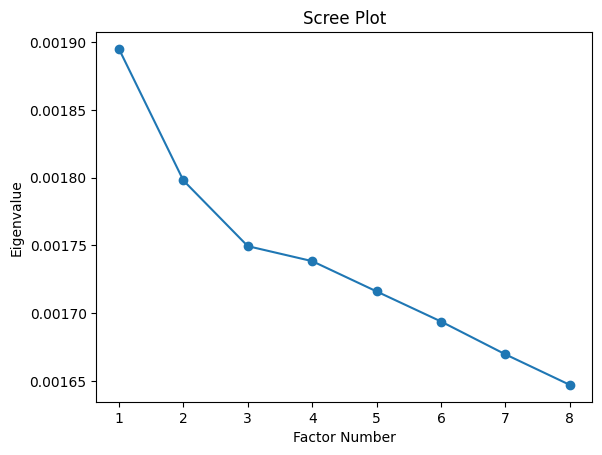

In [10]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA().fit(embeddings)
eigenvalues = pca.explained_variance_

# Find number of factors where eigenvalues > 1
# n_factors = np.sum(eigenvalues > 1)
# n_factors
import matplotlib.pyplot as plt

plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# n_factors = np.argmax(cumulative_variance >= 0.85) + 1
# n_factors


In [29]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42565 sha256=5f934ea1e3427cb541ae6f36bc7312be0a33c58f208d085e087c93c0a14149d6
  Stored in directory: /home/sara/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor-analyzer

[notice] A new release of pip is available: 23.3.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


Factor Loadings:
 [[-0.00640596 -0.00211268 -0.00380706 -0.00490633 -0.00071671  0.00207778
  -0.0033237   0.00306854]
 [ 0.00031213  0.00389392 -0.00081322 -0.00043589 -0.00293706  0.00088823
   0.00382811  0.00466238]]


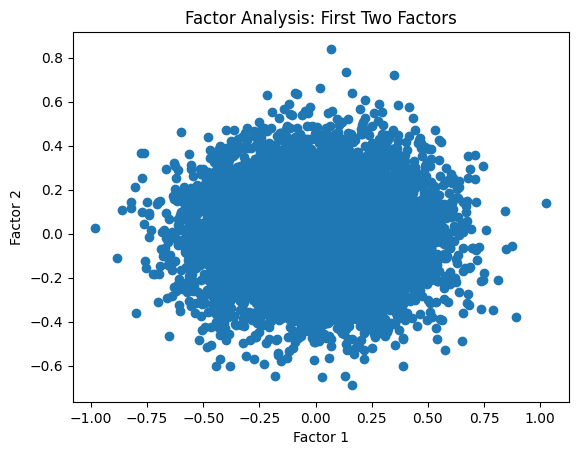

In [15]:
from sklearn.decomposition import FactorAnalysis

n_factors = 2
fa = FactorAnalysis(n_components=n_factors)
factors = fa.fit_transform(embeddings)
# Print the factor loadings

print("Factor Loadings:\n", fa.components_)

# Visualize the first two factors
plt.scatter(factors[:, 0], factors[:, 1])
plt.title('Factor Analysis: First Two Factors')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.show()

In [163]:
# ! pip install numpy --upgrade

## Embedding Dimension reduction

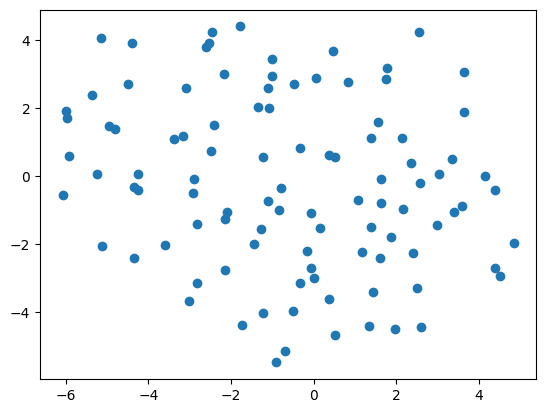

In [7]:
# projecting the skill embedding vectors to 2d dimension

# features = df.loc[:, :'petal_width']
# umap_2d = UMAP(n_components=2, n_neighbors=8, init='random', random_state=0)
# X = umap_2d.fit_transform(X)

X_tsne = TSNE(init='pca').fit_transform(X)
import matplotlib.pyplot as plt

plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.show()

## Compute Clusters

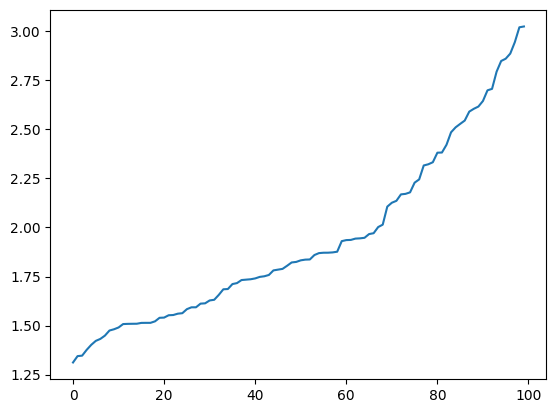

In [348]:
# trick to find the best value of epsilon for DBSCAN, the point of maximum curvature is the optimal epsilon
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=15)
neighbors_fit = neighbors.fit(X_tsne)
distances, indices = neighbors_fit.kneighbors(X_tsne)
distances = numpy.sort(distances, axis=0)
# print(distances[:, 1])
distances = distances[:,-1]
plt.plot(distances)

In [8]:
# clustering of the embedding values


db = KMeans(n_clusters=5).fit(X_tsne)
# db = DBSCAN(eps=1.5, min_samples=9).fit(X_tsne)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 5
Estimated number of noise points: 0


## Plot results

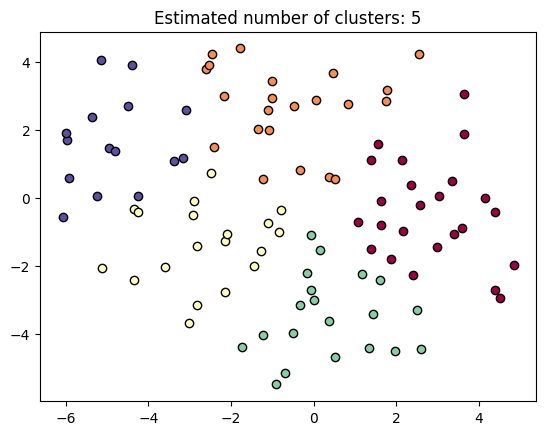

In [11]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
# core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_tsne[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_tsne[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()


## Analysing the clusters

In [18]:
df_fig = df.copy()
df_fig['tsne-2d-one'] = X_tsne[:,0]
df_fig['tsne-2d-two'] = X_tsne[:,1]
df_fig['score'] = rewards
df_fig['clusters'] = labels
df_cluster = df_fig.sort_values('clusters')

# df_cluster = df_fig.query('`tsne-2d-one` > 1').query('`tsne-2d-two` > -2').sort_values('score')
# df_fig
df_cluster

,latent,action_0,action_1,action_2,action_3,action_5,action_4,tsne-2d-one,tsne-2d-two,score,clusters
0,"[tensor(-0.0514), tensor(-0.0526), tensor(-0.0...",0.978261,0.004348,0.011594,0.005797,0.000000,0.000000,2.992098,-1.428309,0.0,0
39,"[tensor(-0.0059), tensor(-0.0762), tensor(-0.0...",0.979710,0.004348,0.011594,0.004348,0.000000,0.000000,4.389963,-2.713880,0.0,0
41,"[tensor(-0.0342), tensor(-0.0610), tensor(0.01...",0.784314,0.147059,0.062745,0.005882,0.000000,0.000000,2.412254,-2.273589,75.0,0
42,"[tensor(0.0072), tensor(-0.0307), tensor(-0.00...",0.557500,0.245000,0.135000,0.025000,0.007500,0.030000,1.880262,-1.778659,110.0,0
43,"[tensor(-0.0762), tensor(0.0164), tensor(-0.03...",0.827451,0.109804,0.056863,0.003922,0.000000,0.001961,1.389998,1.128839,75.0,0
...,...,...,...,...,...,...,...,...,...,...,...
79,"[tensor(0.0532), tensor(-0.0777), tensor(0.041...",0.456522,0.114493,0.110145,0.018841,0.102899,0.197101,-5.380885,2.384131,165.0,4
70,"[tensor(0.0859), tensor(0.0573), tensor(0.0010...",0.764516,0.217742,0.009677,0.003226,0.003226,0.001613,-6.080951,-0.555021,320.0,4
47,"[tensor(0.0704), tensor(-0.0186), tensor(0.024...",0.525000,0.140385,0.184615,0.059615,0.021154,0.069231,-4.820864,1.375471,45.0,4
29,"[tensor(0.0677), tensor(-0.0432), tensor(-0.00...",0.584615,0.200000,0.151282,0.051282,0.001282,0.011538,-4.396386,3.928682,250.0,4
